In [ ]:
import os
import yaml

import anndata as ad
from joblib import Parallel, delayed
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import numpy as np
import pandas as pd
from scipy.spatial.distance import cdist
from scipy.stats import spearmanr
import seaborn as sns


In [2]:
LOOP_DIR = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/inverse/loss_guidance/bloodplus_inverse_fm_old_measurements_official"
TARGET_CT_NAME = "late_MgkPro"

opt_modes = os.listdir(LOOP_DIR)
opt_modes_dirs = [os.path.join(LOOP_DIR, opt_mode, TARGET_CT_NAME) for opt_mode in opt_modes]

runs_to_load = []
for idx, opt_dir in enumerate(opt_modes_dirs):
    opt_mode = opt_modes[idx]

    runs = os.listdir(opt_dir)
    runs_dir = [os.path.join(opt_dir, run) for run in runs]

    runs_to_load.extend(runs_dir)

len(runs_to_load)

744

In [3]:
def load_dir(run_dir):

    config_path = os.path.join(run_dir, "config.yaml")

    fwd_results_path = os.path.join(run_dir, "fwd_results.npz")
    inv_results_path = os.path.join(run_dir, "inverse_results.npz")

    candidates_path = os.path.join(run_dir, "candidates.csv")
    candidates_unc_path = os.path.join(run_dir, "uncertainty_annotation", "candidates_with_uncertainties.csv")
    candidates_counterf_path = os.path.join(run_dir, "uncertainty_annotation", "candidates_with_uncertainties_next_loop.csv")

    with open(config_path, "r") as fb:
        config = yaml.safe_load(fb)

    fwd_results = dict(np.load(fwd_results_path))
    inv_results = dict(np.load(inv_results_path))

    cand_df =  pd.read_csv(candidates_path)
    cand_unc_df =  pd.read_csv(candidates_unc_path)
    cand_counterf_df =  pd.read_csv(candidates_counterf_path)

    return {
        "Configuration": config,
        "Forward Results": fwd_results,
        "Inverse Results": inv_results,
        "Candidates Original": cand_df,
        "Candidates Uncertainty": cand_unc_df,
        "Candidates Counterfactual": cand_counterf_df,
    }

n_jobs = 100
raw_data = Parallel(n_jobs=n_jobs)(delayed(load_dir)(i) for i in runs_to_load)


In [4]:
candidates_df = pd.concat(
    [e['Candidates Original'] for e in raw_data], axis=0
)

uncertainty_df = pd.concat(
    [e['Candidates Uncertainty'] for e in raw_data], axis=0
)

counterfactual_df = pd.concat(
    [e['Candidates Counterfactual'] for e in raw_data], axis=0
)

In [10]:
ADATA_PATH = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/loops/data/loop1/adata_500k_residual.h5ad"

adata_res_loop1 = ad.read_h5ad(ADATA_PATH)
print(adata_res_loop1)

protocol_cols = raw_data[0]["Configuration"]["annotation"]["protocol_columns"]
resc_protocol_cols = [f"{c}:rescaled" for c in protocol_cols]

adata_210 = adata_res_loop1[adata_res_loop1.obs.experiment_number == 210].copy()
sakurai_condition = adata_210.obs[protocol_cols].astype(float).drop_duplicates()
sakurai_condition_log1p = pd.DataFrame(np.log1p(sakurai_condition.values), columns=protocol_cols, index=sakurai_condition.index)
sakurai_condition

AnnData object with n_obs × n_vars = 20490 × 20
    obs: 'experiment_number', 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC-A :: FSC - Area', 'FSC-H :: FSC - Height', 'FSC-W :: FSC - Width', 'SSC-A :: SSC - Area', 'SSC-H :: SSC - Height', 'SSC-W :: SSC - Width', 'TIME', 'NA', 'AF Index', 'batch', '7-AAD', 'leiden', 'leiden_sub', 'leiden_old', 'cell_type'
    var: 'n', 'channel', 'marker', 'PnB', 'PnE', 'PnR', 'PnD', 'signal_type', 'antibody'
    uns: 'cell_type_colors', 'leiden', 'leiden_colors', 'leiden_colors_old', 

,gm-csf_[ng_ml],tpo_[ng_ml],sr1_[nm],um171_[nm],um729_[µm],scf_[ng_ml],butyzamide_[nm],retinoic_acid_[µm],ldl_[ng_ml],il3_[ng_ml],o2_[%],days_of_culture
124883-707,0.0,0.0,0.0,70.0,0.0,0.0,100.0,0.0,0.0,0.0,20.0,14.0


In [12]:
def filter_opt_results(candidates_df, lbound_dict, ubound_dict,  margin = 0.1):
    # ----  Target Markers Loop ----
    print("---- Filtering Results ----")
    # define mask for all columns
    marker_mask = np.full(candidates_df.shape[0], True)

    # ----  Protocol Columns Loop ----
    for col, col_ubound in ubound_dict.items():
        # get col bounds
        col_lbound = lbound_dict[col]
        print(f"\t\t---- Processing Column {col} -> U: {col_ubound}, L: {col_lbound} ----")

        # get col values and mask
        col_values = candidates_df[col]
        col_mask_ubound_mask = col_values <= col_ubound*(1 + margin)
        col_mask_lbound_mask = col_values >= col_lbound*(1 - margin)

        # get masks for current column
        old_mask = marker_mask
        lbound_marker_mask = marker_mask & col_mask_lbound_mask
        ubound_marker_mask = marker_mask & col_mask_ubound_mask
        marker_mask = marker_mask & col_mask_ubound_mask & col_mask_lbound_mask

        # get number of solutions
        n_previously_accepted_solutions = old_mask.sum()
        n_accepted_solutions = marker_mask.sum()
        n_solutions_passing_ubound = col_mask_ubound_mask.sum()
        n_solutions_passing_lbound = col_mask_lbound_mask.sum()
        n_solutions_passing_ubound_and_previous_constraints = ubound_marker_mask.sum()
        n_solutions_passing_lbound_and_previous_constraints = lbound_marker_mask.sum()
        print(f"\t\t\t --- Number Previously Accepted Solutions {n_previously_accepted_solutions} ---")
        print(f"\t\t\t --- Number Currently Accepted Solutions {n_accepted_solutions} ---")
        print(f"\t\t\t --- Number of Solution Satisfying Upper Bound {n_solutions_passing_ubound} ---")
        print(f"\t\t\t --- Number of Solution Satisfying Lower Bound {n_solutions_passing_lbound} ---")
        print(f"\t\t\t --- Number of Solution Satisfying Upper Bound and Previous Constraints {n_solutions_passing_ubound_and_previous_constraints} ---")
        print(f"\t\t\t --- Number of Solution Satisfying Lower Bound and Previous Constraints {n_solutions_passing_lbound_and_previous_constraints} ---")


        # write values for constraint on current column
        candidates_df[f"passes_constraints:{col}:ubound"] = col_mask_ubound_mask
        candidates_df[f"passes_constraints:{col}:lbound"] = col_mask_ubound_mask

    # write values for all constraints
    n_all_solutions = candidates_df.shape[0]
    n_accepted_solutions = marker_mask.sum()
    candidates_df["passes_constraints:all"] = marker_mask

    print(f"\t\t\t--- Finished, Out of {n_all_solutions} there are {n_accepted_solutions} Passing with Margin {margin} ----")
    return candidates_df

In [13]:
constraints_config_path = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/collab-goettgens-SFC/inverse/loss_guidance/config/constraints/default_all_cols.yaml"
with open(constraints_config_path, "r") as fb:
    constraints_config = yaml.safe_load(fb)
ubound_dict = constraints_config["ubound_dict"]
lbound_dict = constraints_config["lbound_dict"]

candidates_df = filter_opt_results(candidates_df, lbound_dict, ubound_dict)

mask = candidates_df["passes_constraints:all"]

filtered_candidates = candidates_df[mask].copy()
filtered_uncertainty = uncertainty_df[mask].copy()
filtered_counterfactual = counterfactual_df[mask].copy()


---- Filtering Results ----
		---- Processing Column gm-csf_[ng_ml] -> U: 10.0, L: 0.0 ----
			 --- Number Previously Accepted Solutions 37200 ---
			 --- Number Currently Accepted Solutions 34785 ---
			 --- Number of Solution Satisfying Upper Bound 34785 ---
			 --- Number of Solution Satisfying Lower Bound 37200 ---
			 --- Number of Solution Satisfying Upper Bound and Previous Constraints 34785 ---
			 --- Number of Solution Satisfying Lower Bound and Previous Constraints 37200 ---
		---- Processing Column tpo_[ng_ml] -> U: 2.5, L: 0.0 ----
			 --- Number Previously Accepted Solutions 34785 ---
			 --- Number Currently Accepted Solutions 30333 ---
			 --- Number of Solution Satisfying Upper Bound 31757 ---
			 --- Number of Solution Satisfying Lower Bound 37200 ---
			 --- Number of Solution Satisfying Upper Bound and Previous Constraints 30333 ---
			 --- Number of Solution Satisfying Lower Bound and Previous Constraints 34785 ---
		---- Processing Column um171_[nm] -> U: 1120.0, 

In [50]:
columns = [
    "late_MgkPro_prop_std",
    "late_MgkPro_prop",
]


candidates_conditions = filtered_candidates[protocol_cols]
candidates_conditions_log1p = pd.DataFrame(filtered_candidates[resc_protocol_cols].values, columns=protocol_cols, index=candidates_conditions.index)

metrics_loop0 = filtered_uncertainty[columns].copy()

dist_sakurai = cdist(candidates_conditions_log1p.values, sakurai_condition_log1p.values)


metrics_loop0["Sakurai Distance"] = dist_sakurai


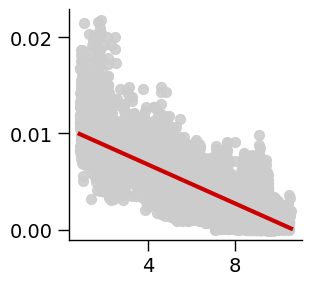

In [70]:
# --- Compute correlation (same as before) ---
rho, pval = spearmanr(metrics_loop0["Sakurai Distance"],
                      metrics_loop0["late_MgkPro_prop_std"])

# --- Style constants (color‑blind friendly) ---
dot_color = "#CCCCCC"      # grey dots
line_color = "#CC0000"     # red regression line

# --- Create figure and axis (square, compact) ---
fig, ax = plt.subplots(figsize=(3, 3))

# --- Regression plot (scatter + line, no confidence band) ---
sns.regplot(
    data=metrics_loop0,
    x="Sakurai Distance",
    y="late_MgkPro_prop_std",
    scatter_kws={
        "color": dot_color,
        "s": 50,            # marker size
        "alpha": 0.9,
        # "linewidth": 0      # no edge on markers
    },
    line_kws={
        "color": line_color,
        "linewidth": 3,
        "linestyle": "-"    # solid line
    },
    ci=None,                # remove shaded confidence band
    ax=ax
)

# --- Strip all labels and title ---
ax.set_title('')
ax.set_xlabel('')
ax.set_ylabel('')

# ax.set_xscale("log")
if ax.get_legend():
    ax.get_legend().remove()

# --- Exactly 3 tick marks per axis ---
ax.xaxis.set_major_locator(MaxNLocator(3))
ax.yaxis.set_major_locator(MaxNLocator(3))

# --- Thicken spines and ticks ---
for spine in ax.spines.values():
    spine.set_linewidth(1.0)
ax.tick_params(axis='both', which='major', labelsize=14, length=8, width=1.0)

# --- Despine (remove top & right spines) ---
sns.despine(ax=ax)

# --- Save high‑resolution figure ---
fig.savefig("output/uncertainty_vs_distance_to_MEM.png", dpi=300, bbox_inches='tight')
plt.show()